## **Figure-S17**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np
import os
import re

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pyopenms as po
sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("pyopenms version", po.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
pyopenms version 3.3.0
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(silico='In-Silico',
             bruker='timsTOF\nPanHuman',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reconstructed')

In [4]:
custom_palette = ["tab:cyan", "tab:brown"]
sns.set_palette(custom_palette)

# Use default mpl color cycle
default_colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

condition_palette = {
    condition['orig']: default_colors[0],
    condition['refined']: default_colors[1],
}


# **Load Data**

In [5]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'-(\d+pg)-', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderDiann(diann_dir, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = defaultdict(dict)

    # Define custom sort order for dilutions
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']

    # Get all dilution directories within diann directory
    dilution_dirs = []
    if os.path.isdir(diann_dir):
        dilution_dirs = [d for d in os.listdir(diann_dir) 
                        if os.path.isdir(os.path.join(diann_dir, d))
                        ]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(diann_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            lib_dirs = [d for d in os.listdir(replicate_path) 
                       if os.path.isdir(os.path.join(replicate_path, d))
                       and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, "report.tsv")

                lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists
                if os.path.exists(report_path):
                    try:
                        # Call getPrecursorSetDiann function

                        if replicate == '2':

                            # Store both the result and the library name
                            rslts[dilution_dir][f'Reconstructed (Reference = {lib_dilution})'] = getProteinSetDiann_matcher(report_path, **kwargs)

                            print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
                    except Exception as e:
                        print(f"Error processing {report_path}: {str(e)}")
                else:
                    print(f"Missing report.tsv file in {os.path.join(replicate_path, lib_dir)}")
    return rslts


def appendOriginalResultsDiann(diann_dir, rslts, **kwargs):
    # Get all experiment directories within diann directory
    diann_experiment_dirs = []
    if os.path.isdir(diann_dir):
        diann_experiment_dirs = [d for d in os.listdir(diann_dir) 
                               if os.path.isdir(os.path.join(diann_dir, d)) and '_0pg' not in d and "R2024" not in d]
    
    # Process each directory
    for dir_name in diann_experiment_dirs:
        # Extract dilution and replicate
        dilution, replicate = extract_info(dir_name)
        
        # Path to report.tsv
        report_path = os.path.join(diann_dir, dir_name, "report.tsv")

        # Check if file exists
        if os.path.exists(report_path):
            try:
                # Call getPrecursorSertdiann function
                if replicate == '2':
                    rslts[dilution]['Initial'] = getProteinSetDiann_matcher(report_path, **kwargs)

                print(f"Processed {dir_name} successfully (dilution: {dilution}, replicate: {replicate})")
            except Exception as e:
                print(f"Error processing {dir_name}: {str(e)}")
        else:
            print(f"Skipping {dir_name}: Missing report.tsv file")

In [6]:
diann = {}

diann[names['bruker']] = loadRefinedFolderDiann("../../results/SCP-Bruker-Lib-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-Bruker-Library-Analysis/diann/", diann[names['bruker']])

diann[names['silico']] = loadRefinedFolderDiann("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-PeptDeep-NoMods-Analysis/diann/", diann[names['silico']])

diann[names['diatracer']] = loadRefinedFolderDiann("../../results/SCP-diaTracer-Refined-Analysis/diann/", infer_schema_length=10000)
appendOriginalResultsDiann("../../results/SCP-diaTracer-Analysis/diann", diann[names['diatracer']], infer_schema_length=10000)

../../results/SCP-Bruker-Lib-Refined-Analysis/diann/250pg/HeLa02DDM_250pg_5x3_PyDIA_2_S1-C8_1_1637/2025-06-17-Refine-BrukerLib-2500pg-rep2_lib/report.tsv


Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 15326 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 55 MB (working set delta), 55 MB (peak working set delta)


Aho-Corasick done:
  found 15622 hits for 15326 of 15326 peptides.
Peptide hits passing enzyme filter: 15622
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 15326 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both 

In [7]:
variations_diann = defaultdict(dict)
for dil in ['100pg', '250pg', '500pg', '1000pg', '2500pg', '5000pg']:
    variations_diann[condition['orig']][dil] = avg_jaccard_index({lib:diann[lib][dil]['Initial'] for lib in names.values()})

for dil in ['100pg', '250pg', '500pg', '1000pg', '2500pg']:
    print(dil)
    variations_diann[condition['refined']][dil] = avg_jaccard_index({lib:diann[lib][dil]['Reconstructed (Reference = 5000pg)'] for lib in names.values()})

variations_diann = pd.DataFrame(variations_diann)
variations_diann['Software'] = 'DIA-NN'

variations_diann

100pg
250pg
500pg
1000pg
2500pg


,Initial,Reconstructed,Software
100pg,0.379022,0.714403,DIA-NN
250pg,0.431474,0.725506,DIA-NN
500pg,0.521167,0.735797,DIA-NN
1000pg,0.615790,0.738299,DIA-NN
2500pg,0.665661,0.724012,DIA-NN
5000pg,0.714949,NaN,DIA-NN


#### **Load Data - OSW**

In [8]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = defaultdict(dict)

    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'\d+pg', d) 
                        ]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        if dilution_dir == '0pg':
            continue
        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            if alt_lib_dir:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                        if os.path.isdir(os.path.join(replicate_path, d))
                        and d.startswith('lib')]
            else:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                           if os.path.isdir(os.path.join(replicate_path, d))
                           and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                    
                if alt_lib_dir:
                    lib_dilution = extract_lib_info_alt(lib_dir)
                else:
                    lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists, if not use pyprophet fallback
                if not os.path.exists(report_path):
                        report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )
                if replicate in ['2']:
                    if lib_dilution != dilution_dir:
                        rslts[dilution_dir][f'Reconstructed (Reference = {lib_dilution})'] = getProteinSet_matcher(report_path)
                        print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
    return rslts

def appendOriginalResultsOSW(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'\d+pg', d) ]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        print(dilution_dir)
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if dilution == '0':
            continue
        report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
        print(report_path)
        
        # Check if file exists, if not use pyprophet fallback
        if not os.path.exists(report_path):
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
        
        if replicate in ['2']:
            rslts[dilution][condition['orig']] = getProteinSet_matcher(report_path)
            print(f"Processed {dilution_dir} rep {replicate} | lib original")
        
def appendOriginalResultsOSWDiaTracer(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'\d+pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:

        dilution_path = os.path.join(osw_dir, dilution_dir)

        runName_dirs = [d for d in os.listdir(os.path.join(osw_dir, dilution_dir)) 
                        if os.path.isdir(os.path.join(osw_dir, dilution_dir, d))
                        and re.search(r'pg', d)]

        if dilution_dir == '0pg':
            continue
        for runName in runName_dirs: 
            dilution, replicate = extract_info(runName)

            report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_folder, runName + ".oswpq")

            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_fallback, runName + ".oswpq/" )
                
            if replicate in ['2']:
                rslts[dilution_dir][condition['orig']] = getProteinSet_matcher(report_path)
                print(f"Processed {dilution_dir} rep {replicate} | lib original")

In [9]:
osw = {}

osw[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", osw[names['bruker']])

osw[names['diatracer']] = loadRefinedFolderOSW("../../results/SCP-diaTracer-Refined-Analysis/osw/", alt_lib_dir=True)
appendOriginalResultsOSWDiaTracer("../../results/SCP-diaTracer-Analysis/osw/", osw[names['diatracer']])

osw[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", osw[names['silico']], pyprophet_folder='pyprophet_SVM')

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631.oswpq/


PeptideIndexer found unmatched peptides, which could not be associated to a protein.
<Unable to determine decoy string (not enough occurrences; <40%)!> occurred 82 times
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 11991 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 14378 hits for 11982 of 11991 peptides.
Peptide hits passing enzyme filter: 14378
     ... rejected by enzyme filter: 0
Unmatched peptide: DAGTIAGLNIVR
Unmatched peptide: PGPALWPLPLSVK
Unmatched peptide: DVDGLTSINAGR
Unmatched peptide: TMQDVVEDFK
Unmatched peptide: QTAEAYLGK
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: DD

Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 12548 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 1 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 14988 hits for 12537 of 12548 peptides.
Peptide hits passing enzyme filter: 14988
     ... rejected by enzyme filter: 0
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: ARFEELNNDLFR
Unmatched peptide: DVDGLTSINAGR
Unmatched peptide: TMQDVVEDFK
Unmatched peptide: QTAEAYLGK
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide:

...

Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 6163 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 7944 hits for 6155 of 6163 peptides.
Peptide hits passing enzyme filter: 7944
     ... rejected by enzyme filter: 0
Unmatched peptide: PGPALWPLPLSVK
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide: QTAEAYLGK
Unmatched peptide: DDLGNTLEK
Unmatched peptide: DAGTIAGLNIVR
Unmatched peptide: DVDGLTSINAGR
Unmatched peptide: DAGT

Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 22071 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 27 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 24772 hits for 22071 of 22071 peptides.
Peptide hits passing enzyme filter: 24772
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 22071 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both  

Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 16108 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 9 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 18455 hits for 16108 of 16108 peptides.
Peptide hits passing enzyme filter: 18455
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 16108 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both   

In [10]:
variations_osw = defaultdict(dict)
for dil in ['100pg', '250pg', '500pg', '1000pg', '2500pg', '5000pg']:
    variations_osw[condition['orig']][dil] = avg_jaccard_index({lib:osw[lib][dil]['Initial'] for lib in names.values()})

for dil in ['100pg', '250pg', '500pg', '1000pg', '2500pg']:
    # just use all refinement with the 5000pg for ease of use
    variations_osw[condition['refined']][dil] = avg_jaccard_index({lib:osw[lib][dil]['Reconstructed (Reference = 5000pg)'] for lib in names.values()})

variations_osw = pd.DataFrame(variations_osw)
variations_osw['Software'] = 'OpenSWATH'

In [11]:
variations_osw

,Initial,Reconstructed,Software
100pg,0.431537,0.660874,OpenSWATH
250pg,0.483275,0.691295,OpenSWATH
500pg,0.549705,0.714349,OpenSWATH
1000pg,0.633252,0.720746,OpenSWATH
2500pg,0.685507,0.725356,OpenSWATH
5000pg,0.726553,NaN,OpenSWATH


In [12]:
variations = pd.concat([variations_diann, variations_osw])

variations = variations.reset_index(names='DilutionName')
variations['Dilution'] = variations['DilutionName'].str.extract(r'(\d+)pg').astype(int)

variations = variations.melt(id_vars=['DilutionName', 'Software', 'Dilution'], var_name='Condition', value_name='Jaccard Index')
variations

,DilutionName,Software,Dilution,Condition,Jaccard Index
0,100pg,DIA-NN,100,Initial,0.379022
1,250pg,DIA-NN,250,Initial,0.431474
2,500pg,DIA-NN,500,Initial,0.521167
3,1000pg,DIA-NN,1000,Initial,0.615790
4,2500pg,DIA-NN,2500,Initial,0.665661
5,5000pg,DIA-NN,5000,Initial,0.714949
6,100pg,OpenSWATH,100,Initial,0.431537
7,250pg,OpenSWATH,250,Initial,0.483275
8,500pg,OpenSWATH,500,Initial,0.549705
9,1000pg,OpenSWATH,1000,Initial,0.633252


In [13]:
def percent_increase(initial, final):
    if initial == 0:
        raise ValueError("Initial value cannot be zero.")
    return ((final - initial) / initial) * 100

In [14]:
percent_increase(0.41, 0.72)

75.60975609756098

I am seeing the desired trends like above.

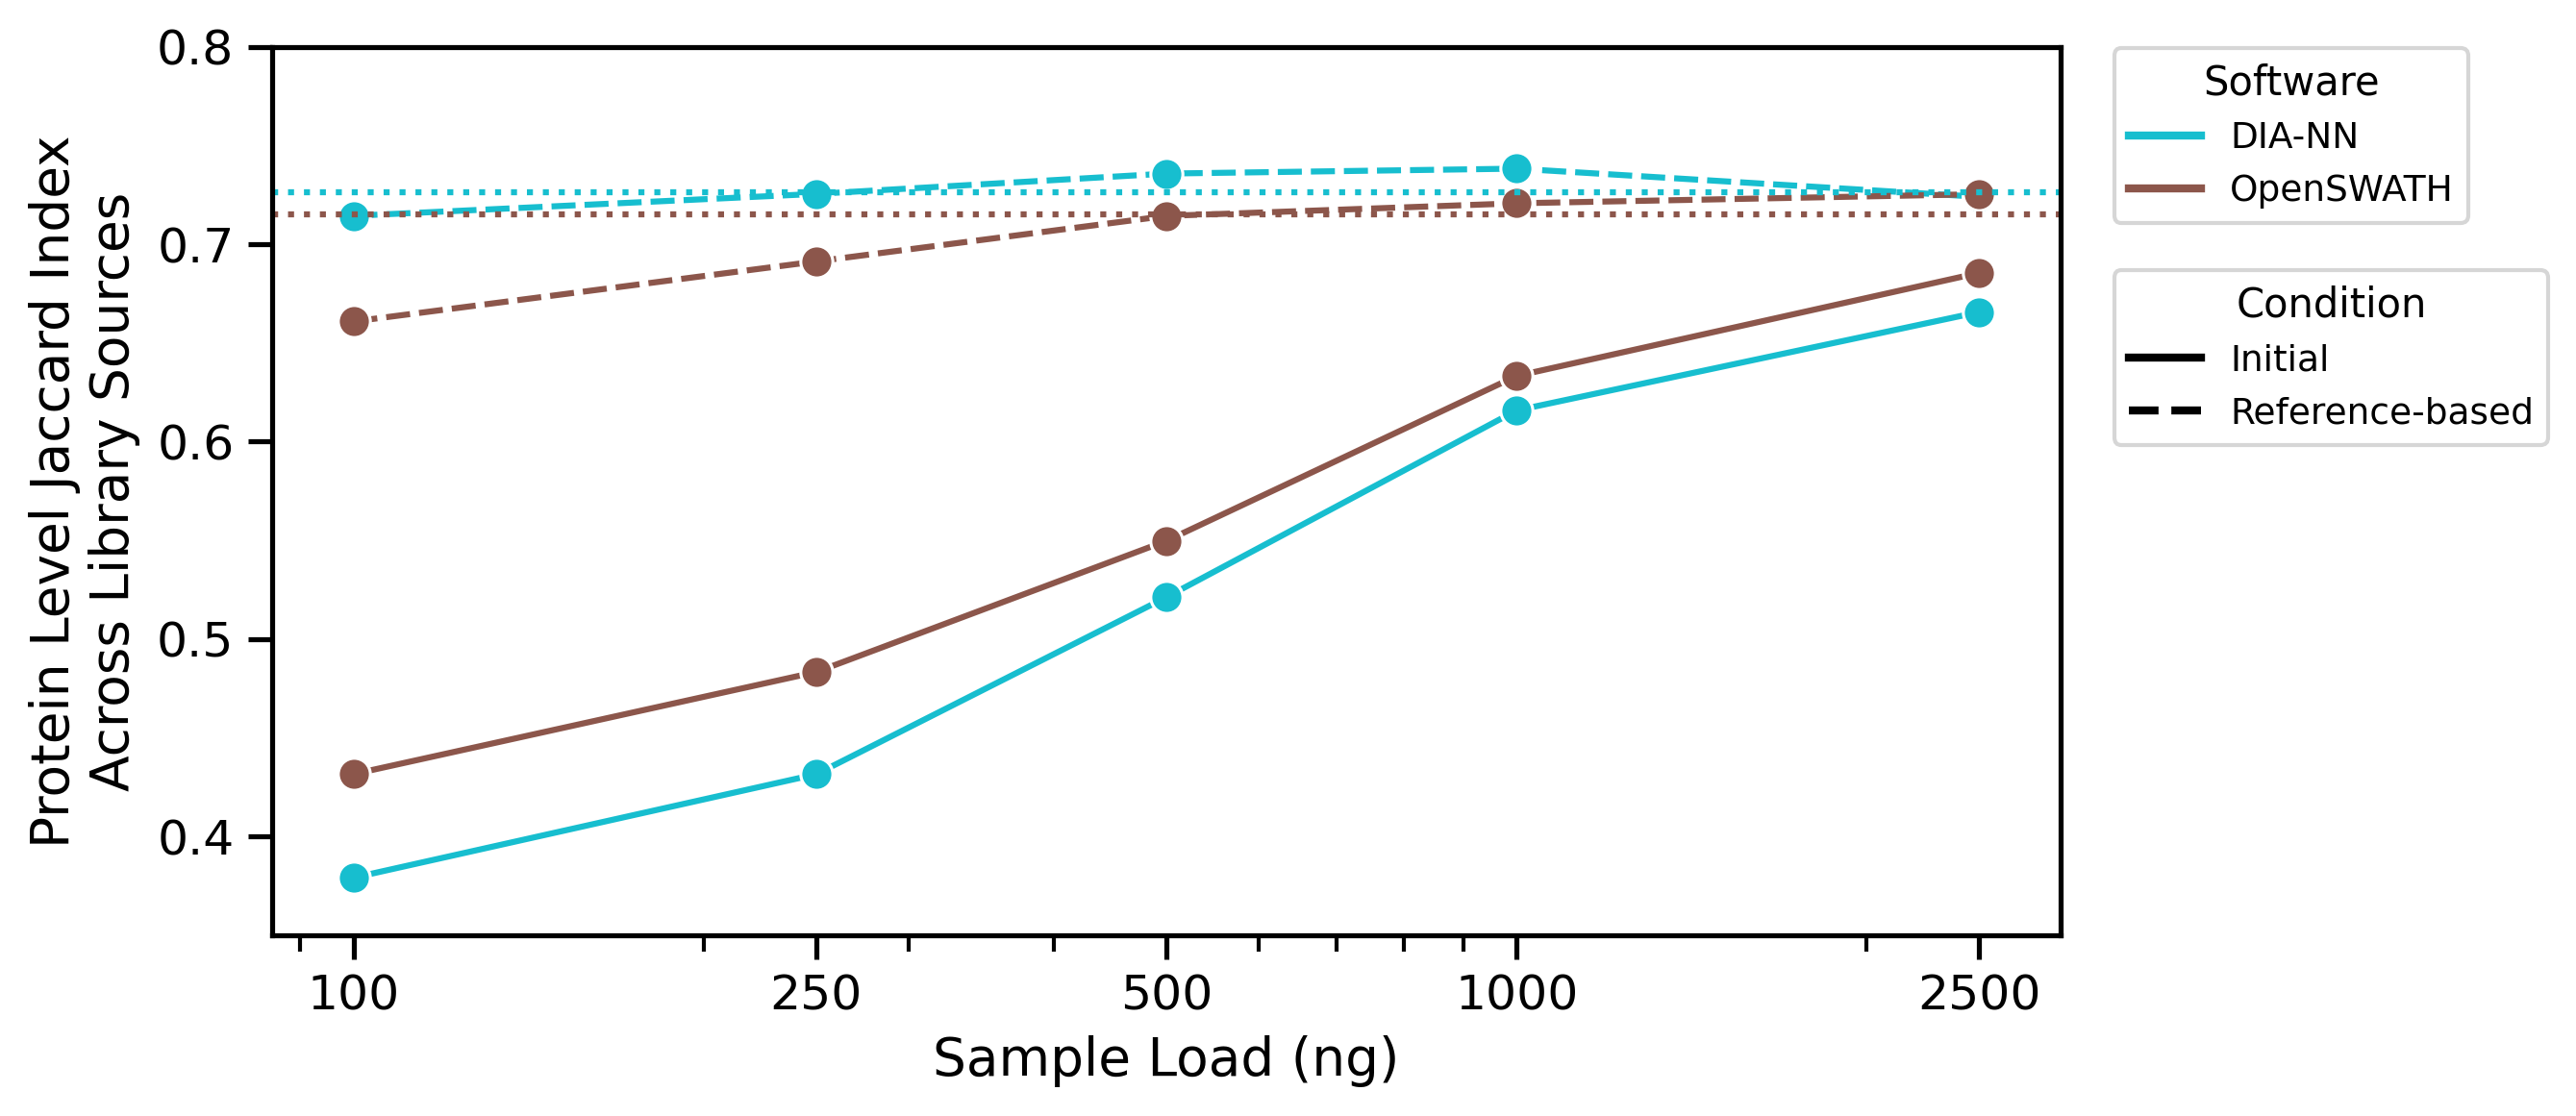

In [15]:
with sns.plotting_context('notebook', font_scale=1.1):
    plt.figure(figsize=(8, 4), dpi=300)
    rslts_osw_5000pg_initial = variations.loc[(variations['Dilution'] == 5000) & (variations['Software'] == 'OpenSWATH') & (variations['Condition'] == 'Initial'), 'Jaccard Index'].iloc[0]
    rslts_diann_5000pg_initial = variations.loc[(variations['Dilution'] == 5000) & (variations['Software'] == 'DIA-NN') & (variations['Condition'] == 'Initial'), 'Jaccard Index'].iloc[0]

    ax = sns.lineplot(data=variations[variations['Dilution'] < 5000], x='Dilution', hue='Software', style='Condition', 
                     y='Jaccard Index', marker='o', markersize=8, style_order=['Initial', 'Reconstructed'])
    
    plt.xscale('log')
    plt.xticks([100, 250, 500, 1000, 2500], ['100', '250', '500', '1000', '2500'])
    plt.xlabel('Sample Load (ng)')
    plt.ylabel("Protein Level Jaccard Index\nAcross Library Sources")
    
    # Remove the automatic legend
    ax.legend().remove()
    
    # Create separate legends
    software_colors = {'DIA-NN': 'tab:cyan', 'OpenSWATH': 'tab:brown'}
    condition_styles = {'Initial': '-', 'Reference-based': '--'}
    
    # Create software legend (colors)
    software_handles = [plt.Line2D([0], [0], color=color, linewidth=2, label=software) 
                       for software, color in software_colors.items()]
    legend1 = ax.legend(handles=software_handles, title='Software', 
                        loc='center left', fontsize=9, title_fontsize=10, 
                        bbox_to_anchor=(1.02, 0.9))
    
    # Create condition legend (line styles)
    condition_handles = [plt.Line2D([0], [0], color='black', linestyle=style, linewidth=2, label=condition)
                        for condition, style in condition_styles.items()]
    legend2 = ax.legend(handles=condition_handles, title='Condition', 
                        loc='center left', fontsize=9, title_fontsize=10,
                        bbox_to_anchor=(1.02, 0.65))
    
    ax.axhline(rslts_osw_5000pg_initial, color=software_colors['DIA-NN'], ls='dotted')
    ax.axhline(rslts_diann_5000pg_initial, color=software_colors['OpenSWATH'], ls='dotted')
    
    # Add the first legend back
    ax.add_artist(legend1)
    ax.set_ylim(0.35, 0.80)
    
    plt.savefig("Figure-S17.png", dpi=300, bbox_inches='tight')